# 6.1.1 采样间隔与混叠

## 学习目标与先修知识

能从连续信号写出采样（sampling）值；用余弦恒等式解释混叠（aliasing）；区分采样间隔、数值求解步长和信号中最快的变化。

先修：函数、时间单位、正弦与余弦的一周为 $2\pi$，以及测量误差和数值误差（numerical error）的区别。可复习[过程与测量的区别](../../05-随机性与信息/02-期望、方差、协方差与噪声/03-过程测量与个体差异.ipynb)和[数值误差与网格细化](../../02-系统随时间演化/04-数值模拟误差与迁移/01-误差与网格细化.ipynb)。

## 具体问题

组织中某种浓度（concentration）围绕基线周期波动。传感器每秒记一次数，图上看起来是缓慢节律。我们能据此认定组织确实变化很慢吗？先去掉噪声，只比较两种不同的理想节律；即使测量完全准确，也可能无法区分它们。

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GRAY = '#008bfb', '#ff0051', '#555555'

## 初步实验

In [2]:
t_observed = np.arange(6, dtype=float)
slow = np.cos(2*np.pi*0.2*t_observed)
fast = np.cos(2*np.pi*0.8*t_observed)
display(Markdown(show_table(['时间 / s','0.2 Hz 的值 / U','0.8 Hz 的值 / U'],zip(t_observed,slow,fast))))
print('相同时间点的最大差异：', float(np.max(np.abs(slow-fast))))

| 时间 / s | 0.2 Hz 的值 / U | 0.8 Hz 的值 / U |
| --- | --- | --- |
| 0 | 1 | 1 |
| 1 | 0.309017 | 0.309017 |
| 2 | -0.809017 | -0.809017 |
| 3 | -0.809017 | -0.809017 |
| 4 | 0.309017 | 0.309017 |
| 5 | 1 | 1 |

相同时间点的最大差异： 9.43689570931383e-16


## 模型假设

只研究一个标量观测（observation）通道。$x(t)=B\cos(2\pi f t+\phi)$ 表示相对基线的浓度偏差，单位为 U，因此允许负数；这不意味着绝对浓度为负。$B\ge0$ 是振幅（amplitude），$f\ge0$ 是频率（frequency），单位 Hz，即每秒周期数；$\phi$ 为相位（phase），单位 rad。它们都是教学参数（parameter）。

本节设测量映射为 $y_n=x(t_n)$，没有传感器响应延迟（delay）、噪声、时间抖动或舍入。规则采样时 $t_n=n\Delta t$，采样率（sampling rate）$f_s=1/\Delta t$。观察范围有限；知道这几项值不等于知道整个连续函数。

## 数学解释与推导

余弦每增加 $2\pi$ 就重复，因此整数 $m$ 满足

$$\cos\left(2\pi(f+m f_s)\frac{n}{f_s}+\phi\right)
=\cos\left(2\pi f\frac{n}{f_s}+\phi+2\pi mn\right)
=\cos\left(2\pi f\frac{n}{f_s}+\phi\right).$$

对零相位余弦，再利用 $\cos(-\theta)=\cos\theta$，$f$ 与 $f_s-f$ 的样本也相同。例中 $f_s=1$ Hz，故 0.2 与 0.8 Hz 重合。非零相位不能直接照搬：折返频率时相位的符号也要相应变换。

奈奎斯特频率（Nyquist frequency）$f_s/2$ 是规则采样频率轴的折返边界。理想采样定理的常用充分条件是：连续信号带限（band-limited），在 $|f|>f_{\max}$ 无频率成分，且 $f_s>2f_{\max}$；还需精确采样及无限长样本序列等理想前提，才能保证这类信号的唯一重建。它不保证一段有限、有噪声记录已足以恢复任意信号。带通信号的特殊先验（prior）也可能使用不同采样方案，本节不据此放宽通用条件。

等号处有边界反例：$\sin(2\pi(f_s/2)n/f_s)=\sin(\pi n)=0$。每周期两个点也可能完全看不到振荡。实际测量通常预留频率余量：首次 A/D 采样前需用模拟前端抗混叠滤波（anti-aliasing filter）抑制过高频率；对已经以足够高采样率取得的离散序列做降采样，应先数字低通再抽取。首次采样后才做数字滤波，无法恢复已发生的混叠。

数值求解步长 $h$ 控制近似连续方程的误差，采样间隔 $\Delta t$ 控制留下哪些观测。即使内部轨迹（trajectory）用极小 $h$ 算得准确，每秒只保存一次仍会发生同样的混叠；本例有精确余弦，根本不需要数值积分。

## 核心实现

直接在给定时刻评价余弦；返回顺序与输入（input）时间相同，不偷偷生成额外观测。

In [3]:
def sample_cosine(times, frequency, amplitude=1.0, phase=0.0):
    return [float(amplitude*math.cos(2*math.pi*frequency*t+phase)) for t in times]

## 对照实验

只改变采样率。蓝色实线为 0.8 Hz 原节律，灰色虚线为 0.2 Hz 低频候选；玫红标记表示采样读数。在 1 Hz 采样下，两种节律的读数重合；在 4 Hz 下，用实心圆表示原节律读数、空心方块表示候选读数，便于比较它们在哪里分开。连续线来自已知解析模型（model），不是额外测量。

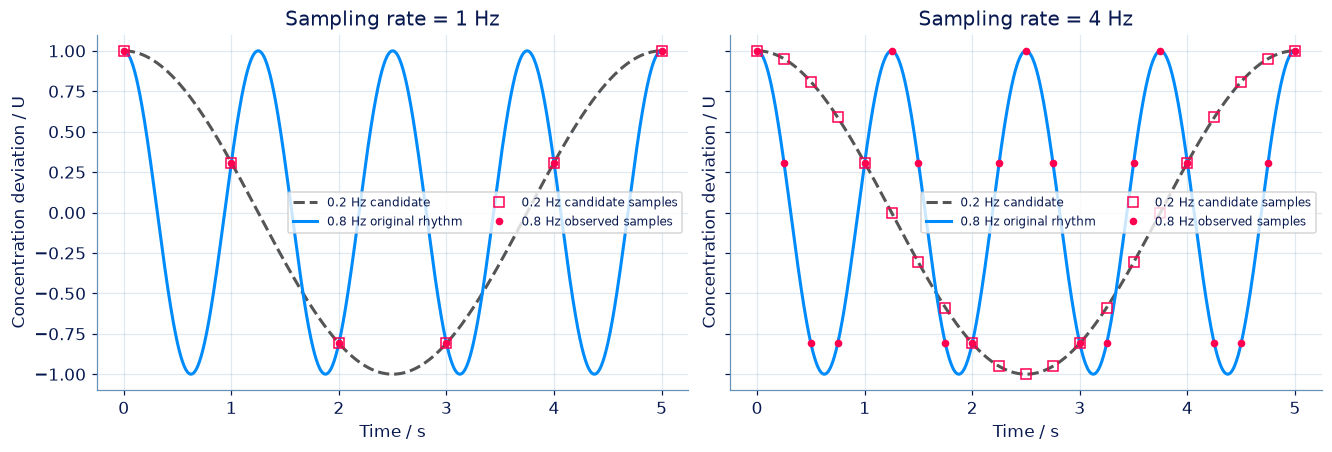

In [4]:
t_dense=np.linspace(0,5,1001)
fig,axes=plt.subplots(1,2,figsize=(12,4),sharey=True)
for ax,fs in zip(axes,[1.,4.]):
    times=np.arange(int(5*fs)+1)/fs
    ax.plot(t_dense,sample_cosine(t_dense,.2),color=GRAY,ls='--',label='0.2 Hz candidate')
    ax.plot(t_dense,sample_cosine(t_dense,.8),color=BLUE,label='0.8 Hz original rhythm')
    ax.plot(times,sample_cosine(times,.2),'s',mfc='none',color=PINK,ms=7,label='0.2 Hz candidate samples')
    ax.plot(times,sample_cosine(times,.8),'o',color=PINK,ms=4,label='0.8 Hz observed samples')
    ax.set(xlabel='Time / s',ylabel='Concentration deviation / U',title=f'Sampling rate = {fs:g} Hz')
    ax.legend(fontsize=8,ncol=2)
plt.show()

## 结果解释

左图的样本重合，但两条连续曲线不同；连点得到的慢曲线只是候选解释。右图增加实际采样点后，这两个候选节律可区分。增加采样点的作用，是让这两个候选节律给出不同的读数。

### 独立核对

用周期恒等式核对混叠，并检查奈奎斯特边界的正弦消失。最后改变实际观测时刻，而不改变内部绘图网格。

In [5]:
times=np.arange(21)/2
np.testing.assert_allclose(sample_cosine(times,.3,2,.4),sample_cosine(times,2.3,2,.4),atol=5e-14)
np.testing.assert_allclose(sample_cosine(np.arange(10),.2),sample_cosine(np.arange(10),.8),atol=1e-14)
np.testing.assert_allclose(np.sin(np.pi*np.arange(20)),0,atol=1e-14)
assert abs(sample_cosine([.25],.2)[0]-sample_cosine([.25],.8)[0])>.5
assert sample_cosine([], .2)==[]
print('频率平移、零相位折返、边界反例与增加真实采样点的检查通过。')

频率平移、零相位折返、边界反例与增加真实采样点的检查通过。


[观察本章的动态可视化](http://127.0.0.1:8000/chapters/06-01-观测、采样与滤波/explore/)：改变采样或窗口条件，比较图形后返回本节推导。

## 练习与参考资料

习题由统一题库同步。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：在指定时刻读取节律

理想节律 x(t)=amplitude*cos(2π*frequency*t+phase)。按给定时刻返回采样（sampling）值，保留原有顺序，不自行插入新的时刻。

**函数与代码模板**

```python
def solve(
    times: list[float],
    frequency: float,
    amplitude: float,
    phase: float,
) -> list[float]:
    # 按题目定义返回计算结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `times` | `list[float]` | 实际观察时刻，可不等间隔。 | s |
| `frequency` | `float` | 连续节律频率。 | Hz |
| `amplitude` | `float` | 节律幅度。 | U |
| `phase` | `float` | 初相位（phase）。 | rad |

**返回值**

直接返回 samples（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `samples` | `list[float]` | 与 times 一一对应的读数。 | U |

**计算规则**

逐个代入给定余弦函数；空时间列表返回空列表；频率不能在代入前被改成混叠（aliasing）频率。

**约束与边界**

- 所有非缺测数值有限；不修改输入（input）列表。
- 0—100 个时刻，0≤t≤100；0≤frequency≤10；0≤amplitude≤10；−π≤phase≤π。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| times | 实际观察时刻，可不等间隔。 | [0, 1, 2] | s |
| frequency | 连续节律频率。 | 0.2 | Hz |
| amplitude | 节律幅度。 | 1 | U |
| phase | 初相位（phase）。 | 0 | rad |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
times = [0, 1, 2]
frequency = 0.2
amplitude = 1.0
phase = 0.0

result = solve(times, frequency, amplitude, phase)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| samples | 与 times 一一对应的读数。 | [1.0, 0.30901699437494745, -0.8090169943749473] | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [1.0,
                   0.30901699437494745,
                   -0.8090169943749473]
```

**样例解释**

整数时刻得到约 [1,0.309017,−0.809017] U；0.8 Hz 在这些时刻给出同一组样本，但两条连续曲线不同。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：在指定时刻读取节律](http://127.0.0.1:8000/chapters/06-01-%E8%A7%82%E6%B5%8B%E3%80%81%E9%87%87%E6%A0%B7%E4%B8%8E%E6%BB%A4%E6%B3%A2/practice/?question=p06-cosine-samples)

### 第 2 题 · 多项选择题：细化哪一个时钟

连续模型（model）用 h=0.01 s 求解，每隔 Δ=1 s 读取一次，滤波用最近 5 个读数。哪些正确？

- **A.** 将 h 减半必定消除观测（observation）混叠（aliasing）。
- **B.** 窗口覆盖最近 5 次观察，等间隔时首尾相距 4 s。
- **C.** 用更密的线连采样（sampling）点就获得新的观测信息。
- **D.** 数值步长、采样间隔和窗口长度是三个不同选择。

[作答：细化哪一个时钟](http://127.0.0.1:8000/chapters/06-01-%E8%A7%82%E6%B5%8B%E3%80%81%E9%87%87%E6%A0%B7%E4%B8%8E%E6%BB%A4%E6%B3%A2/practice/?question=p06-three-clocks)

### 第 3 题 · 单项选择题：相同样本能证明什么

只知道 x[n]=cos(2π*0.2*n)，采样率（sampling rate） 1 Hz；没有给出连续信号带宽限制。哪项成立？

- **A.** 增加同一采样率下的点数必能区分 0.2 Hz 与 0.8 Hz 的零相位（phase）理想余弦。
- **B.** 0.2 Hz 与 0.8 Hz 表示连续曲线处处相同。
- **C.** 真实连续频率必为 0.2 Hz。
- **D.** 0.8 Hz 的零相位余弦也能产生这些样本。

[作答：相同样本能证明什么](http://127.0.0.1:8000/chapters/06-01-%E8%A7%82%E6%B5%8B%E3%80%81%E9%87%87%E6%A0%B7%E4%B8%8E%E6%BB%A4%E6%B3%A2/practice/?question=p06-alias-equivalence)

### 第 4 题 · 多项选择题：采样定理的适用前提

讨论用均匀采样（sampling）恢复连续信号。哪些说法恰当？

- **A.** 先混叠（aliasing）后仅凭这些样本，总能确定原高频。
- **B.** 理想带限（band-limited）信号最高频率为 fmax 时，fs>2fmax 是常用无混叠条件。
- **C.** 有限而带噪的记录自动满足无限精确恢复。
- **D.** 首次 A/D 采样前用模拟前端抗混叠滤波（anti-aliasing filter）；足够高采样率（sampling rate）的离散序列再降采样时，先数字低通再抽取。

[作答：采样定理的适用前提](http://127.0.0.1:8000/chapters/06-01-%E8%A7%82%E6%B5%8B%E3%80%81%E9%87%87%E6%A0%B7%E4%B8%8E%E6%BB%A4%E6%B3%A2/practice/?question=p06-nyquist-conditions)

**进一步阅读**

[MIT 6.003 第 21 讲：Sampling](https://ocw.mit.edu/courses/6-003-signals-and-systems-fall-2011/resources/mit6_003f11_lec21/)：采样与频率复制的补充阅读。